# Track A1 benchmark analysis notebook (readable report view)

This notebook organizes the measurement CSV files into clear tables and plots for:

- Time to first token
- Time per output token
- Output token throughput
- Peak memory usage
- Goodput under the latency service level objective
- Architecture comparison (ARM vs x86)
- BLAS comparison (OpenBLAS Fujitsu vs BLIS)
- Scaling trends (threads, concurrency, context length, decode length)
- Mandatory prompt outputs and quality evidence
- Predicted vs observed time per output token from the performance model


In [13]:
%pip -q install pandas matplotlib seaborn numpy

Note: you may need to restart the kernel to use updated packages.


In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)

ROOT = Path('.').resolve()
MEASUREMENTS = ROOT / 'measurements'

if not MEASUREMENTS.exists():
    raise FileNotFoundError('Could not find measurements directory in the current working directory.')

display(Markdown(f'**Working directory:** `{ROOT}`'))

**Working directory:** `/Users/diogocsilva12/Documents/DeucalionSSH/aded-project-llamacpp`

In [15]:
def read_csv_if_exists(path: Path):
    return pd.read_csv(path) if path.exists() else None

READABLE = MEASUREMENTS / 'readable'
if not READABLE.exists():
    raise FileNotFoundError(
        f'Readable CSV directory not found: {READABLE}. Run: '
        'python3 scripts/parse_readable_a1_outputs.py measurements --prompts prompts/track_a_prompts.json --out-dir measurements/readable'
    )

paths = {
    'all_prompt_rows': READABLE / 'a1_summary.csv',
    'all_scaling_rows': READABLE / 'a1_scaling_summary.csv',
    'mandatory_quality': READABLE / 'mandatory_answer_quality.csv',
    'all_request_metrics': READABLE / 'all_request_metrics.csv',
    'prompt_answers': READABLE / 'prompt_answers.csv',
    'mandatory_prompt_answers': READABLE / 'mandatory_prompt_answers.csv',
    'answer_summary': READABLE / 'answer_summary.csv',
    'request_errors': READABLE / 'request_errors.csv',
    'prompt_catalog': READABLE / 'prompt_catalog.csv',
    'performance_model': MEASUREMENTS / 'report_artifacts' / 'performance_model.csv',
}

datasets = {name: read_csv_if_exists(path) for name, path in paths.items()}

for name, df in datasets.items():
    status = f'loaded with shape {df.shape}' if df is not None else 'missing'
    print(f'{name:24s}: {status}')


def infer_arch(row):
    text = ' '.join(str(row.get(c, '')) for c in ['experiment_dir', 'run_dir', 'engine'])
    if 'x86' in text:
        return 'x86'
    return 'arm'


def normalize_summary_rows(df):
    if df is None:
        return None
    out = df.copy()
    if 'arch' not in out.columns:
        out['arch'] = out.apply(infer_arch, axis=1)
    if 'sweep_id' not in out.columns:
        out['sweep_id'] = out['experiment_dir'].astype(str).str.split('/').str[-1]
    for col in [
        'threads', 'threads_batch', 'ctx_size', 'parallel_requests', 'max_tokens',
        'runs', 'successful_runs', 'ttft_s_mean', 'ttft_s_stdev', 'tpot_s_mean',
        'tpot_s_stdev', 'throughput_output_tok_s_mean', 'throughput_output_tok_s_stdev',
        'goodput_sla_fraction', 'max_rss_kb', 'max_vmhwm_kb'
    ]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    out['cache_pair'] = out['cache_type_k'].astype(str) + '/' + out['cache_type_v'].astype(str)
    return out


def make_readable_table(df, suite=None, engines=None, model_label=None):
    if df is None:
        return None
    work = df.copy()
    if suite is not None:
        work = work[work['suite'].eq(suite)].copy()
    if engines is not None:
        work = work[work['engine'].isin(engines)].copy()
    if model_label is not None:
        work = work[work['model_label'].eq(model_label)].copy()
    if 'successful_runs' in work.columns:
        work = work[pd.to_numeric(work['successful_runs'], errors='coerce').fillna(0) > 0].copy()
    if work.empty:
        return pd.DataFrame()

    group_cols = [
        'sweep_id', 'arch', 'engine', 'model_label', 'threads', 'ctx_size',
        'parallel_requests', 'cache_type_k', 'cache_type_v', 'max_tokens'
    ]
    agg = (
        work.groupby(group_cols, dropna=False)
        .agg(
            **{
                'TTFT mean (seconds)': ('ttft_s_mean', 'mean'),
                'TPOT mean (milliseconds/token)': ('tpot_s_mean', lambda s: s.mean() * 1000.0),
                'Throughput mean (output tokens/second)': ('throughput_output_tok_s_mean', 'mean'),
                'Goodput SLA fraction': ('goodput_sla_fraction', 'mean'),
                'Peak memory VmHWM (GiB)': ('max_vmhwm_kb', lambda s: s.max() / (1024.0 * 1024.0)),
                'Prompt count': ('prompt_id', 'nunique'),
                'Successful runs': ('successful_runs', 'sum'),
            }
        )
        .reset_index()
    )
    agg = agg.rename(columns={
        'sweep_id': 'Sweep',
        'arch': 'Architecture',
        'engine': 'Engine',
        'model_label': 'Model',
        'threads': 'Threads',
        'ctx_size': 'Context tokens',
        'parallel_requests': 'Concurrent requests',
        'max_tokens': 'Max generated tokens',
    })
    agg['KV cache K/V'] = agg['cache_type_k'].astype(str) + '/' + agg['cache_type_v'].astype(str)
    return agg.drop(columns=['cache_type_k', 'cache_type_v']).sort_values(['Architecture', 'Engine', 'Model', 'KV cache K/V']).reset_index(drop=True)


prompt_rows = normalize_summary_rows(datasets['all_prompt_rows'])
datasets['all_prompt_rows'] = prompt_rows

datasets['baseline_readable'] = make_readable_table(prompt_rows, suite='model-set')
datasets['thread_scaling_readable'] = make_readable_table(prompt_rows, suite='thread-scaling', model_label='model-1-mandatory')
datasets['concurrency_readable'] = make_readable_table(prompt_rows, suite='concurrency', model_label='model-1-mandatory')
datasets['context_length_readable'] = make_readable_table(prompt_rows, suite='context-length', model_label='model-1-mandatory')
datasets['decode_length_readable'] = make_readable_table(prompt_rows, suite='decode-length', model_label='model-1-mandatory')
datasets['architecture_readable'] = datasets['baseline_readable']
datasets['blas_readable'] = make_readable_table(
    prompt_rows,
    suite='model-set',
    engines=['vanilla-openblas-fujitsu', 'vanilla-blis'],
    model_label='model-1-mandatory',
)
datasets['model_set_readable'] = datasets['baseline_readable']

print('\nDerived notebook tables:')
for name in [
    'baseline_readable', 'thread_scaling_readable', 'concurrency_readable',
    'context_length_readable', 'decode_length_readable', 'architecture_readable',
    'blas_readable', 'model_set_readable'
]:
    df = datasets.get(name)
    status = f'shape {df.shape}' if df is not None else 'missing'
    print(f'{name:24s}: {status}')


all_prompt_rows         : loaded with shape (1377, 33)
all_scaling_rows        : loaded with shape (1377, 21)
mandatory_quality       : loaded with shape (1377, 15)
all_request_metrics     : loaded with shape (4131, 28)
prompt_answers          : loaded with shape (4131, 24)
mandatory_prompt_answers: loaded with shape (1377, 24)
answer_summary          : loaded with shape (1377, 18)
request_errors          : loaded with shape (84, 24)
prompt_catalog          : loaded with shape (31, 5)
performance_model       : missing

Derived notebook tables:
baseline_readable       : shape (24, 16)
thread_scaling_readable : shape (38, 16)
concurrency_readable    : shape (35, 16)
context_length_readable : shape (28, 16)
decode_length_readable  : shape (28, 16)
architecture_readable   : shape (24, 16)
blas_readable           : shape (2, 16)
model_set_readable      : shape (24, 16)


## Metric glossary (expanded names)

All abbreviations are expanded here for report readability.

In [16]:
metric_glossary = pd.DataFrame([
    {'Metric abbreviation': 'TTFT', 'Expanded metric name': 'Time to first token', 'Unit': 'seconds', 'Description': 'Delay from request submission to first generated token'},
    {'Metric abbreviation': 'TPOT', 'Expanded metric name': 'Time per output token', 'Unit': 'milliseconds per token', 'Description': 'Average inter-token latency during decoding'},
    {'Metric abbreviation': 'Throughput', 'Expanded metric name': 'Output token throughput', 'Unit': 'tokens per second', 'Description': 'Generated output tokens per second'},
    {'Metric abbreviation': 'Peak memory', 'Expanded metric name': 'Peak memory usage (VmHWM)', 'Unit': 'GiB', 'Description': 'Maximum observed high-water-mark resident memory'},
    {'Metric abbreviation': 'Goodput', 'Expanded metric name': 'Latency service-level goodput fraction', 'Unit': 'fraction [0, 1]', 'Description': 'Fraction meeting Time to first token <= 2 seconds and Time per output token <= 200 milliseconds'},
])
display(metric_glossary)

,Metric abbreviation,Expanded metric name,Unit,Description
0,TTFT,Time to first token,seconds,Delay from request submission to first generat...
1,TPOT,Time per output token,milliseconds per token,Average inter-token latency during decoding
2,Throughput,Output token throughput,tokens per second,Generated output tokens per second
3,Peak memory,Peak memory usage (VmHWM),GiB,Maximum observed high-water-mark resident memory
4,Goodput,Latency service-level goodput fraction,"fraction [0, 1]",Fraction meeting Time to first token <= 2 seco...


## Track and assignment requirement checks

This section checks model coverage and mandatory model presence directly from loaded measurements.

In [17]:
prompt_rows = datasets['all_prompt_rows']
if prompt_rows is None:
    raise FileNotFoundError('combined prompt rows file is required for analysis.')

prompt_rows = prompt_rows.copy()
prompt_rows['model_file'] = prompt_rows['model'].astype(str).str.split('/').str[-1]

unique_models = sorted(prompt_rows['model_file'].dropna().unique())
has_mandatory_model = any('Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf' in m for m in unique_models)

summary_checks = pd.DataFrame([
    {'Check': 'Unique model count', 'Value': len(unique_models), 'Requirement': 'At least 3', 'Pass': len(unique_models) >= 3},
    {'Check': 'Mandatory model included', 'Value': has_mandatory_model, 'Requirement': 'Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf present', 'Pass': bool(has_mandatory_model)},
    {'Check': 'Architectures observed', 'Value': ', '.join(sorted(prompt_rows['arch'].dropna().unique())), 'Requirement': 'Architecture comparison should include ARM and x86 when available', 'Pass': True},
    {'Check': 'Engines observed', 'Value': ', '.join(sorted(prompt_rows['engine'].dropna().unique())), 'Requirement': 'Engine variants should be compared', 'Pass': True},
])

display(summary_checks)
display(pd.DataFrame({'Detected model files': unique_models}))

,Check,Value,Requirement,Pass
0,Unique model count,4,At least 3,True
1,Mandatory model included,True,Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf present,True
2,Architectures observed,"arm, x86",Architecture comparison should include ARM and...,True
3,Engines observed,"tq, vanilla, vanilla-blis, vanilla-openblas-fu...",Engine variants should be compared,True


,Detected model files
0,Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf
1,SmolLM2-360M-Instruct.Q4_K_M.gguf
2,gemma-4-E4B-it-OBLITERATED-Q4_K_M.gguf
3,gpt-oss-20b-Q4_K_M.gguf


## Baseline table and metric comparison

Baseline across engines and architectures using full metric names.

,Sweep,Architecture,Engine,Model,Threads,Context tokens,Concurrent requests,Max generated tokens,TTFT mean (seconds),TPOT mean (milliseconds/token),Throughput mean (output tokens/second),Goodput SLA fraction,Peak memory VmHWM (GiB),Prompt count,Successful runs,KV cache K/V
0,1256104-track-a1-server-sweep,arm,tq,model-1-mandatory,24,2048,1,128,0.663780,145.852863,6.271844,0.888889,4.805908,9,27,turbo2/turbo2
1,1256104-track-a1-server-sweep,arm,tq,model-1-mandatory,24,2048,1,128,0.678253,155.223775,5.904861,0.888889,4.830994,9,27,turbo3/turbo3
2,1256104-track-a1-server-sweep,arm,tq,model-1-mandatory,24,2048,1,128,0.665940,147.427282,6.206419,0.888889,4.865356,9,27,turbo4/turbo4
3,1256104-track-a1-server-sweep,arm,tq,model-3,24,2048,1,128,1.569285,147.317343,2.572762,0.222222,5.185974,9,27,turbo2/turbo2
4,1256104-track-a1-server-sweep,arm,tq,model-3,24,2048,1,128,4.887265,166.752551,2.594009,0.111111,5.197205,9,27,turbo3/turbo3
5,1256104-track-a1-server-sweep,arm,tq,model-3,24,2048,1,128,14.499156,157.370523,0.479266,0.111111,5.217346,9,27,turbo4/turbo4
6,1256104-track-a1-server-sweep,arm,tq,model-4,24,2048,1,128,13.332961,158.066302,0.256749,0.000000,10.944580,9,27,turbo2/turbo2
7,1256104-track-a1-server-sweep,arm,tq,model-4,24,2048,1,128,7.010544,160.814848,0.118223,0.000000,10.977478,9,27,turbo3/turbo3
8,1256104-track-a1-server-sweep,arm,tq,model-4,24,2048,1,128,6.121594,157.541011,0.132627,0.000000,10.735962,9,27,turbo4/turbo4
9,1256104-track-a1-server-sweep,arm,vanilla,model-1-mandatory,24,2048,1,128,0.680278,131.272592,6.949324,0.888889,5.256470,9,27,f16/f16


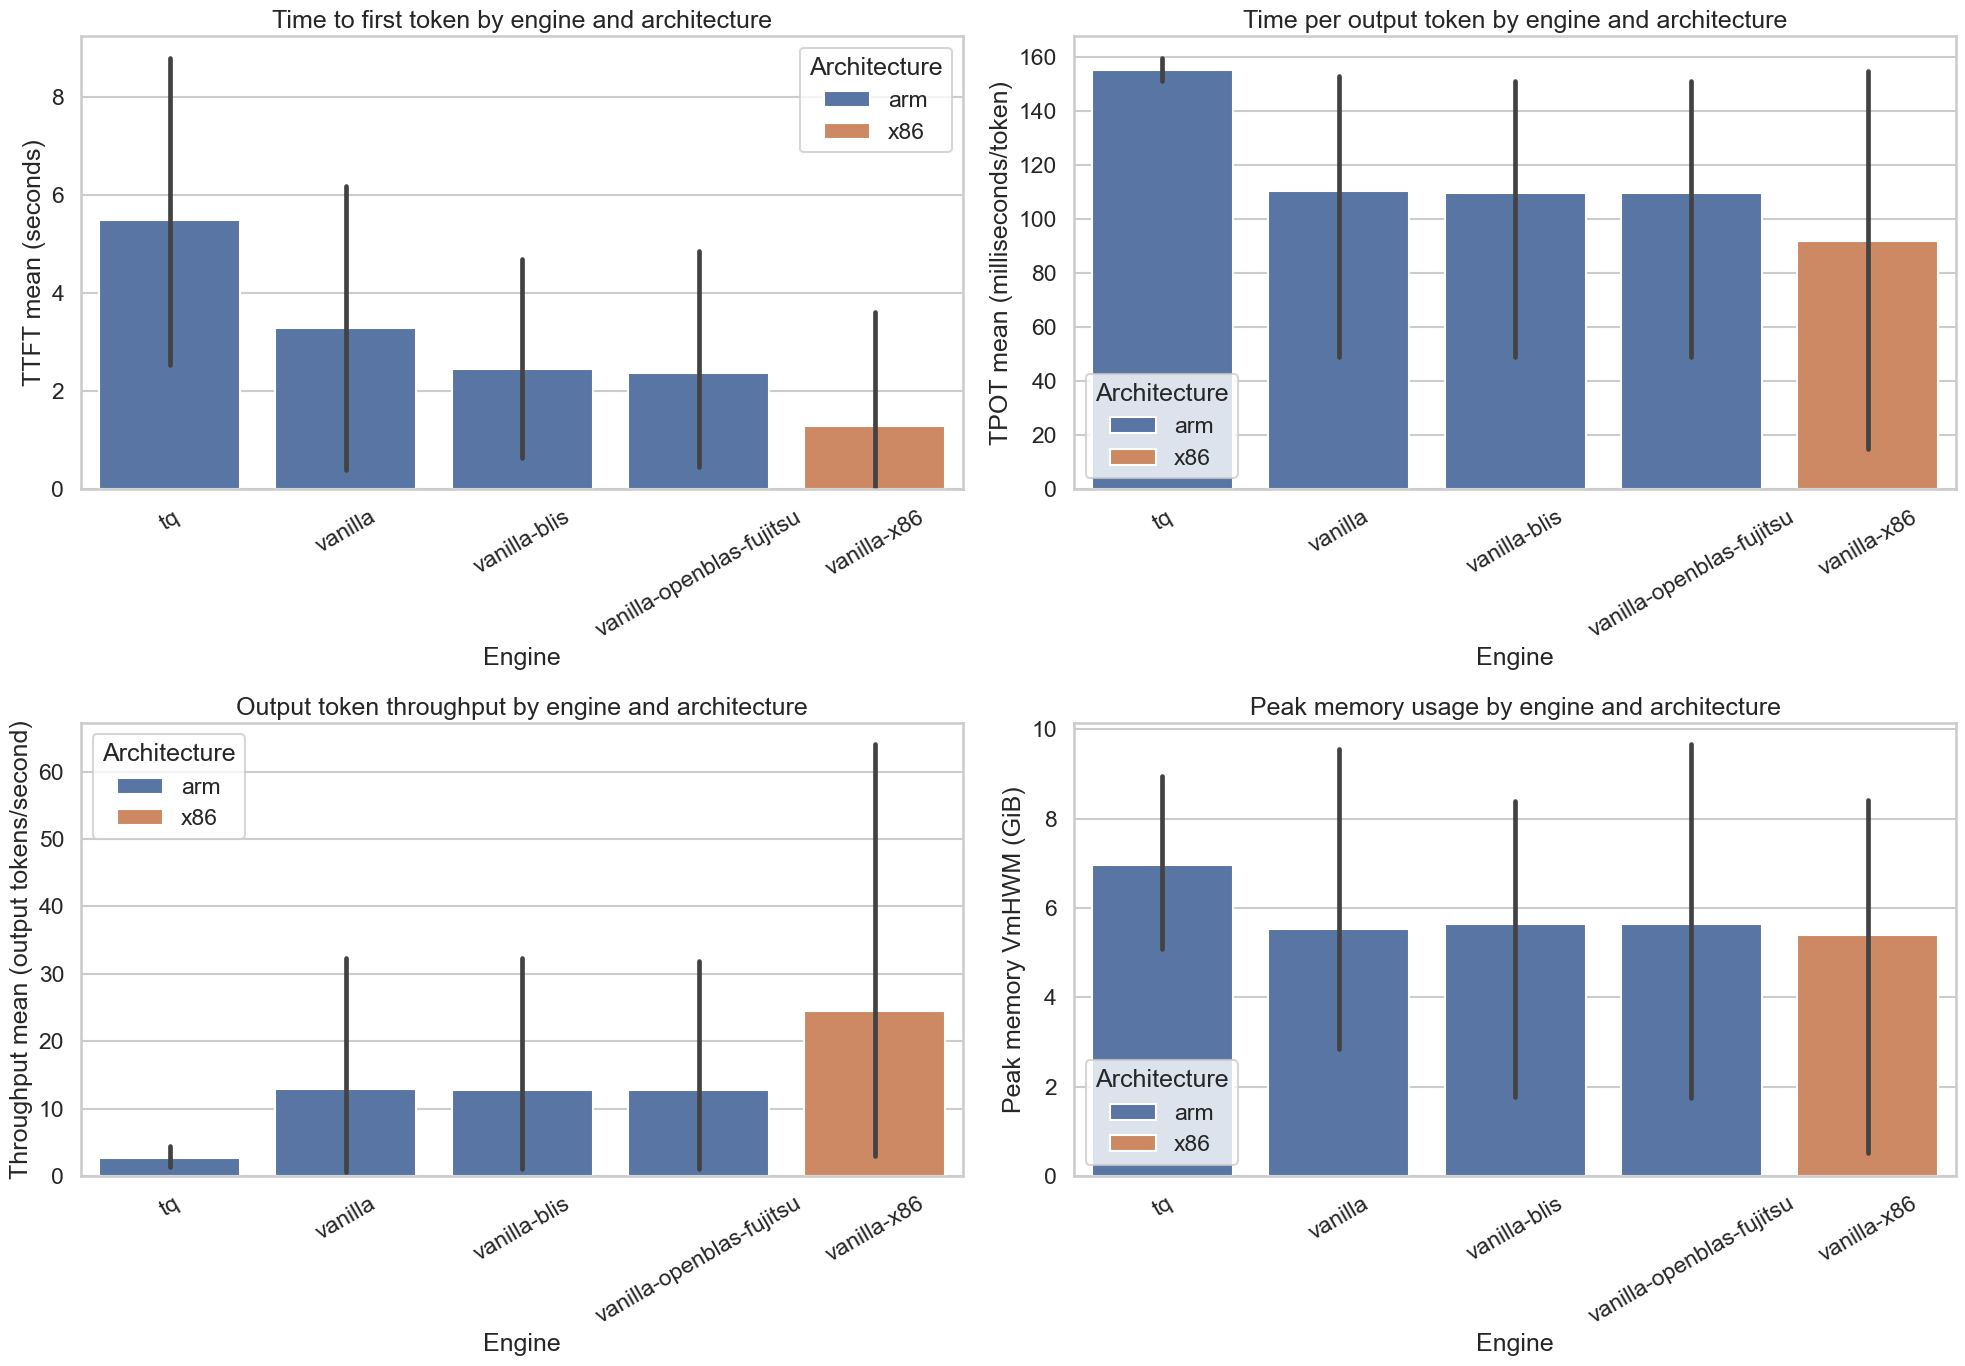

In [18]:
baseline = datasets['baseline_readable']
if baseline is None:
    raise FileNotFoundError('baseline_readable.csv is required for baseline analysis.')

display(baseline.sort_values(['Architecture', 'Engine', 'Model']).reset_index(drop=True))

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
sns.barplot(data=baseline, x='Engine', y='TTFT mean (seconds)', hue='Architecture', ax=axes[0, 0])
axes[0, 0].set_title('Time to first token by engine and architecture')

sns.barplot(data=baseline, x='Engine', y='TPOT mean (milliseconds/token)', hue='Architecture', ax=axes[0, 1])
axes[0, 1].set_title('Time per output token by engine and architecture')

sns.barplot(data=baseline, x='Engine', y='Throughput mean (output tokens/second)', hue='Architecture', ax=axes[1, 0])
axes[1, 0].set_title('Output token throughput by engine and architecture')

sns.barplot(data=baseline, x='Engine', y='Peak memory VmHWM (GiB)', hue='Architecture', ax=axes[1, 1])
axes[1, 1].set_title('Peak memory usage by engine and architecture')

for ax in axes.ravel():
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## BLAS comparison (ARM vanilla variants)

Direct comparison of OpenBLAS Fujitsu and BLIS variants.

,Sweep,Architecture,Engine,Model,Threads,Context tokens,Concurrent requests,Max generated tokens,TTFT mean (seconds),TPOT mean (milliseconds/token),Throughput mean (output tokens/second),Goodput SLA fraction,Peak memory VmHWM (GiB),Prompt count,Successful runs,KV cache K/V
0,1256106-track-a1-vanilla-blas-sweep,arm,vanilla-blis,model-1-mandatory,24,2048,1,128,1.288725,131.524248,6.781331,0.888889,5.509644,9,27,f16/f16
1,1256106-track-a1-vanilla-blas-sweep,arm,vanilla-openblas-fujitsu,model-1-mandatory,24,2048,1,128,0.744251,131.394988,6.924115,0.888889,5.476440,9,27,f16/f16


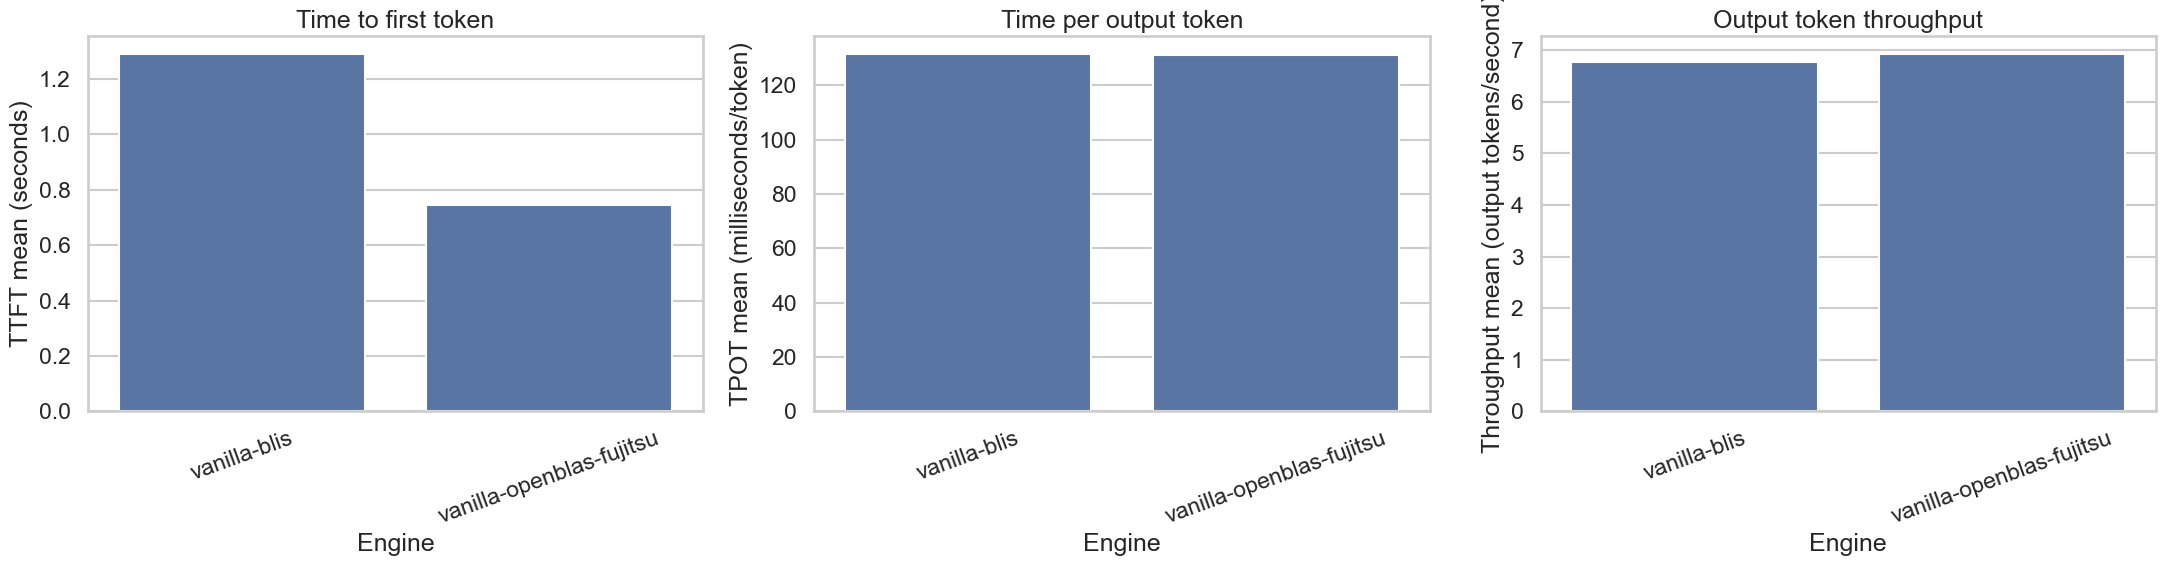

In [19]:
blas = datasets['blas_readable']
if blas is not None and len(blas) > 0:
    display(blas)
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    sns.barplot(data=blas, x='Engine', y='TTFT mean (seconds)', ax=axes[0])
    axes[0].set_title('Time to first token')
    sns.barplot(data=blas, x='Engine', y='TPOT mean (milliseconds/token)', ax=axes[1])
    axes[1].set_title('Time per output token')
    sns.barplot(data=blas, x='Engine', y='Throughput mean (output tokens/second)', ax=axes[2])
    axes[2].set_title('Output token throughput')
    for ax in axes:
        ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown('BLAS comparison table was not found.'))

## Architecture comparison (ARM vs x86)

Focused architecture comparison for the mandatory model baseline.

,Sweep,Architecture,Engine,Model,Threads,Context tokens,Concurrent requests,Max generated tokens,TTFT mean (seconds),TPOT mean (milliseconds/token),Throughput mean (output tokens/second),Goodput SLA fraction,Peak memory VmHWM (GiB),Prompt count,Successful runs,KV cache K/V
0,1256104-track-a1-server-sweep,arm,tq,model-1-mandatory,24,2048,1,128,0.663780,145.852863,6.271844,0.888889,4.805908,9,27,turbo2/turbo2
1,1256104-track-a1-server-sweep,arm,tq,model-1-mandatory,24,2048,1,128,0.678253,155.223775,5.904861,0.888889,4.830994,9,27,turbo3/turbo3
2,1256104-track-a1-server-sweep,arm,tq,model-1-mandatory,24,2048,1,128,0.665940,147.427282,6.206419,0.888889,4.865356,9,27,turbo4/turbo4
3,1256104-track-a1-server-sweep,arm,tq,model-3,24,2048,1,128,1.569285,147.317343,2.572762,0.222222,5.185974,9,27,turbo2/turbo2
4,1256104-track-a1-server-sweep,arm,tq,model-3,24,2048,1,128,4.887265,166.752551,2.594009,0.111111,5.197205,9,27,turbo3/turbo3
5,1256104-track-a1-server-sweep,arm,tq,model-3,24,2048,1,128,14.499156,157.370523,0.479266,0.111111,5.217346,9,27,turbo4/turbo4
6,1256104-track-a1-server-sweep,arm,tq,model-4,24,2048,1,128,13.332961,158.066302,0.256749,0.000000,10.944580,9,27,turbo2/turbo2
7,1256104-track-a1-server-sweep,arm,tq,model-4,24,2048,1,128,7.010544,160.814848,0.118223,0.000000,10.977478,9,27,turbo3/turbo3
8,1256104-track-a1-server-sweep,arm,tq,model-4,24,2048,1,128,6.121594,157.541011,0.132627,0.000000,10.735962,9,27,turbo4/turbo4
9,1256104-track-a1-server-sweep,arm,vanilla,model-1-mandatory,24,2048,1,128,0.680278,131.272592,6.949324,0.888889,5.256470,9,27,f16/f16


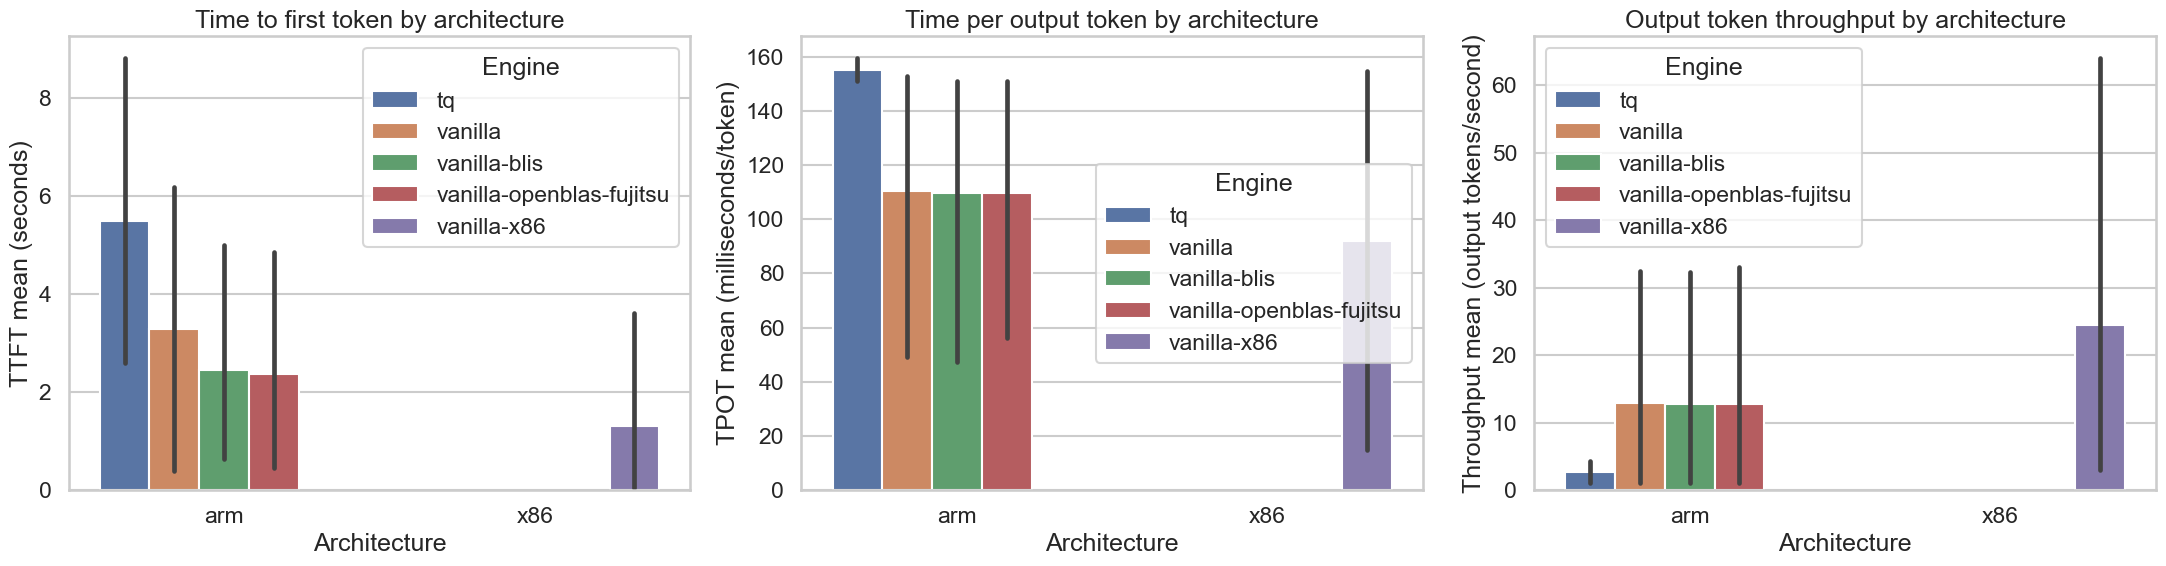

In [20]:
arch_cmp = datasets['architecture_readable']
if arch_cmp is not None and len(arch_cmp) > 0:
    display(arch_cmp)
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    sns.barplot(data=arch_cmp, x='Architecture', y='TTFT mean (seconds)', hue='Engine', ax=axes[0])
    axes[0].set_title('Time to first token by architecture')
    sns.barplot(data=arch_cmp, x='Architecture', y='TPOT mean (milliseconds/token)', hue='Engine', ax=axes[1])
    axes[1].set_title('Time per output token by architecture')
    sns.barplot(data=arch_cmp, x='Architecture', y='Throughput mean (output tokens/second)', hue='Engine', ax=axes[2])
    axes[2].set_title('Output token throughput by architecture')
    plt.tight_layout()
    plt.show()
else:
    display(Markdown('Architecture comparison table was not found.'))

## Scaling analysis

Trend plots for thread count, request concurrency, context length, and decode length.

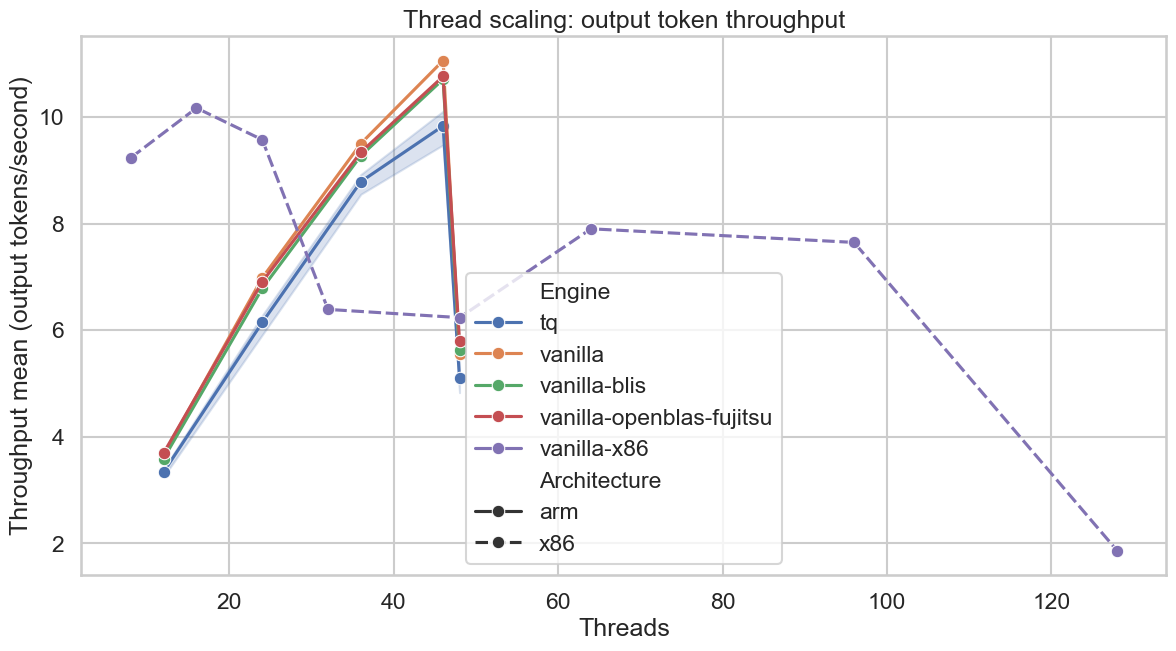

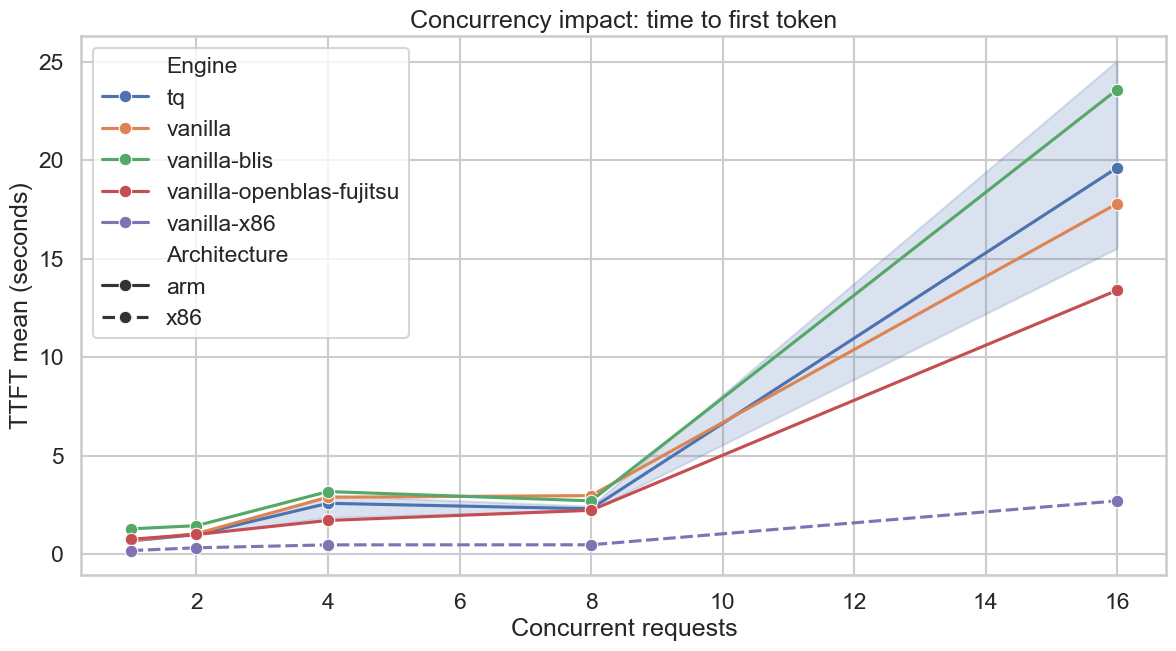

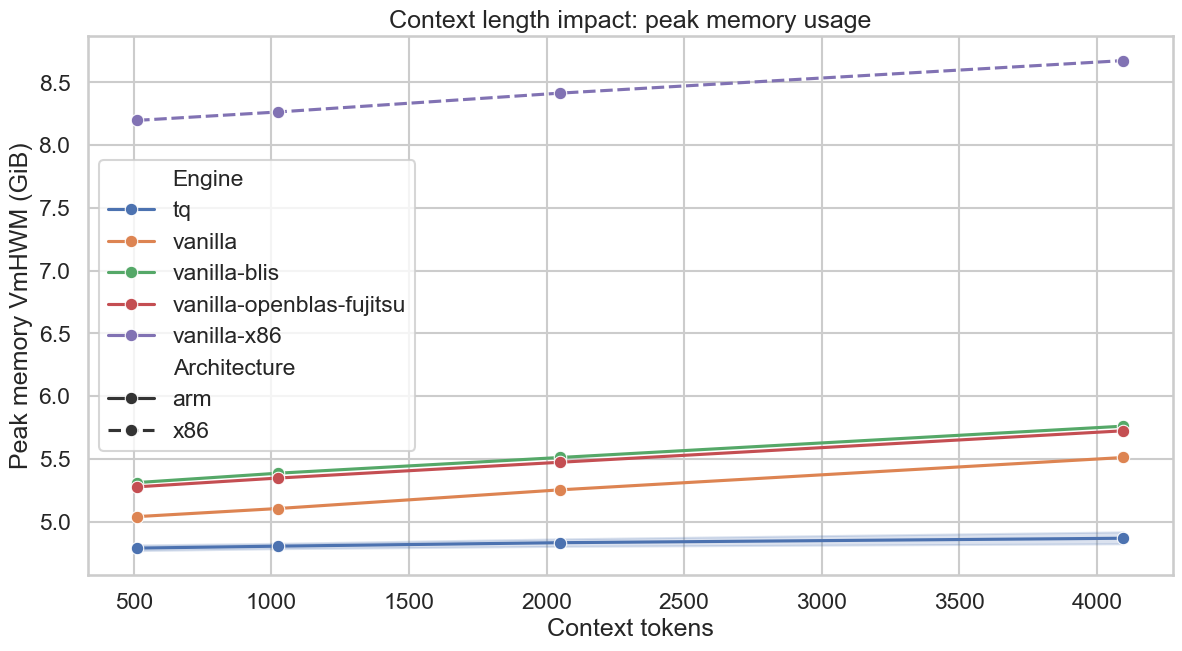

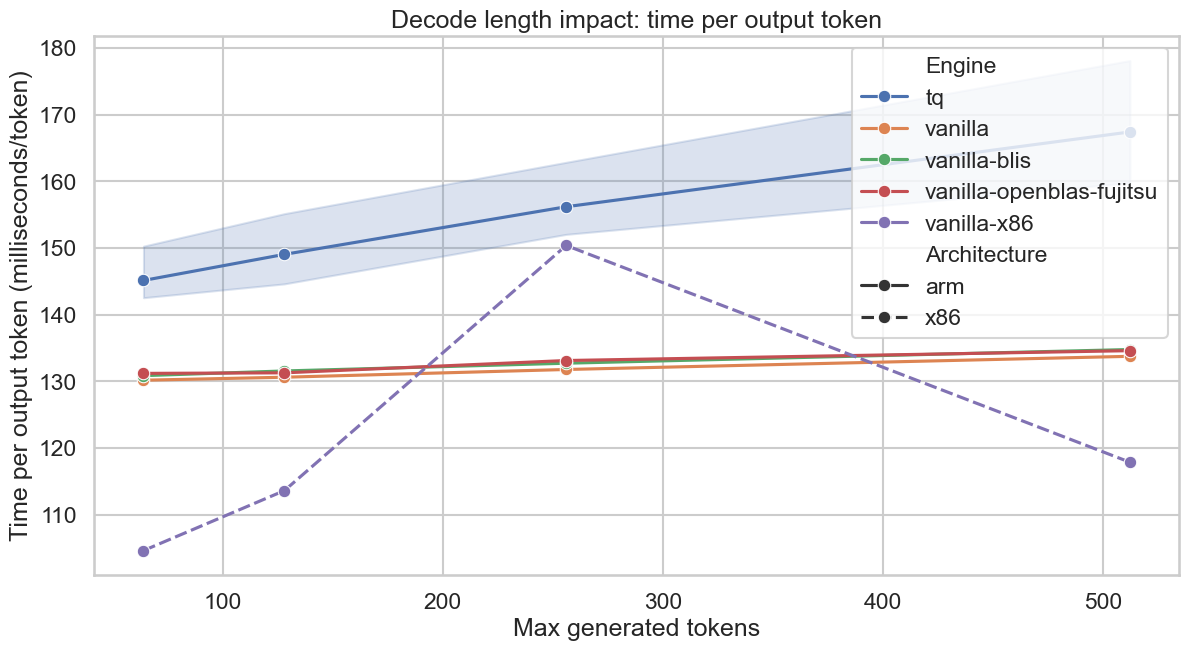

In [21]:
thread_df = datasets['thread_scaling_readable']
conc_df = datasets['concurrency_readable']
ctx_df = datasets['context_length_readable']
dec_df = datasets['decode_length_readable']

if thread_df is not None and len(thread_df) > 0:
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=thread_df, x='Threads', y='Throughput mean (output tokens/second)', hue='Engine', style='Architecture', marker='o')
    plt.title('Thread scaling: output token throughput')
    plt.show()

if conc_df is not None and len(conc_df) > 0:
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=conc_df, x='Concurrent requests', y='TTFT mean (seconds)', hue='Engine', style='Architecture', marker='o')
    plt.title('Concurrency impact: time to first token')
    plt.show()

if ctx_df is not None and len(ctx_df) > 0:
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=ctx_df, x='Context tokens', y='Peak memory VmHWM (GiB)', hue='Engine', style='Architecture', marker='o')
    plt.title('Context length impact: peak memory usage')
    plt.show()

if dec_df is not None and len(dec_df) > 0:
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=dec_df, x='Max generated tokens', y='TPOT mean (milliseconds/token)', hue='Engine', style='Architecture', marker='o')
    plt.title('Decode length impact: time per output token')
    plt.ylabel('Time per output token (milliseconds/token)')
    plt.show()

## Mandatory prompts: outputs, quality, and latency metrics

This section ties generated output quality to measured latency metrics for the three required prompts.

In [22]:
quality = datasets['mandatory_quality']
if quality is None:
    display(Markdown('mandatory_quality.csv is missing.'))
else:
    mandatory_prompt_rows = prompt_rows[prompt_rows['prompt_id'].astype(str).str.startswith('mandatory_')].copy()
    metric_cols = ['run_dir', 'prompt_id', 'category', 'ttft_s_mean', 'tpot_s_mean', 'throughput_output_tok_s_mean', 'goodput_sla_fraction', 'max_vmhwm_kb']
    metric_cols = [c for c in metric_cols if c in mandatory_prompt_rows.columns]
    mandatory_metrics = mandatory_prompt_rows[metric_cols].drop_duplicates()

    merged = quality.merge(mandatory_metrics, how='left', on=['run_dir', 'prompt_id', 'category'])
    merged['time_to_first_token_seconds'] = merged['ttft_s_mean']
    merged['time_per_output_token_milliseconds'] = merged['tpot_s_mean'] * 1000.0
    merged['output_token_throughput_tokens_per_second'] = merged['throughput_output_tok_s_mean']
    merged['peak_memory_gib'] = merged['max_vmhwm_kb'] / (1024.0 * 1024.0)

    quality_summary = (
        merged.groupby(['prompt_id', 'quality_label'], dropna=False)
        .size()
        .reset_index(name='count')
        .sort_values(['prompt_id', 'count'], ascending=[True, False])
    )
    display(quality_summary)

    display_columns = [
        'prompt_id', 'quality_label', 'quality_notes',
        'time_to_first_token_seconds', 'time_per_output_token_milliseconds',
        'output_token_throughput_tokens_per_second', 'peak_memory_gib', 'generated_text'
    ]
    display_columns = [c for c in display_columns if c in merged.columns]

    representative = (
        merged.sort_values(['prompt_id', 'trial'])
        .groupby('prompt_id', as_index=False)
        .first()[display_columns]
    )
    display(representative)

,prompt_id,quality_label,count
0,mandatory_long_transformer_cpu,acceptable,225
1,mandatory_long_transformer_cpu,good,129
3,mandatory_long_transformer_cpu,weak,69
2,mandatory_long_transformer_cpu,missing,36
4,mandatory_medium_ml_vs_dl,acceptable,318
5,mandatory_medium_ml_vs_dl,good,105
6,mandatory_medium_ml_vs_dl,missing,21
7,mandatory_medium_ml_vs_dl,weak,15
8,mandatory_short_capital_france,good,459


,prompt_id,quality_label,quality_notes,time_to_first_token_seconds,time_per_output_token_milliseconds,output_token_throughput_tokens_per_second,peak_memory_gib,generated_text
0,mandatory_long_transformer_cpu,weak,missing: mentions quantisation; explains quant...,19.345284,1882.948198,0.506916,4.841736,"Based on the context provided, the main challe..."
1,mandatory_medium_ml_vs_dl,good,all rubric checks passed,18.656678,2075.171094,0.455737,4.841736,Machine learning (ML) and deep learning (DL) a...
2,mandatory_short_capital_france,good,all rubric checks passed,12.551998,4299.751398,0.176563,4.841736,The capital of France is Paris.


## Readable prompt-answer CSVs

The generated answers are loaded from `measurements/readable/prompt_answers.csv` and split into mandatory-answer, summary, prompt-catalog, and error tables for notebook inspection. Text newlines are escaped as `\n` so each CSV row remains one readable record.


In [23]:
answer_files = pd.DataFrame([
    {'Dataset': name, 'CSV path': str(path.relative_to(ROOT)), 'Rows': None if datasets.get(name) is None else len(datasets[name])}
    for name, path in paths.items()
    if name in {'prompt_answers', 'mandatory_prompt_answers', 'answer_summary', 'request_errors', 'prompt_catalog', 'all_request_metrics'}
])
display(answer_files)

answers = datasets['prompt_answers']
mandatory_answers = datasets['mandatory_prompt_answers']
answer_summary = datasets['answer_summary']
request_errors = datasets['request_errors']

if mandatory_answers is not None and len(mandatory_answers) > 0:
    preview_cols = [
        'suite', 'engine', 'model_label', 'threads', 'ctx_size', 'parallel_requests',
        'cache_type_k', 'cache_type_v', 'prompt_id', 'trial', 'status', 'error',
        'ttft_s', 'tpot_s', 'throughput_output_tok_s', 'generated_text'
    ]
    preview_cols = [c for c in preview_cols if c in mandatory_answers.columns]
    display(Markdown('### Mandatory prompt answer preview'))
    display(mandatory_answers[preview_cols].head(30))

if answer_summary is not None and len(answer_summary) > 0:
    summary_cols = [
        'suite', 'engine', 'model_label', 'threads', 'ctx_size', 'parallel_requests',
        'cache_type_k', 'cache_type_v', 'prompt_id', 'runs', 'successful_runs',
        'error_runs', 'first_success_answer'
    ]
    summary_cols = [c for c in summary_cols if c in answer_summary.columns]
    display(Markdown('### Compact answer summary'))
    display(answer_summary[summary_cols].head(30))

if request_errors is not None and len(request_errors) > 0:
    error_counts = (
        request_errors.groupby(['suite', 'engine', 'model_label', 'prompt_id', 'error'], dropna=False)
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )
    display(Markdown('### Request error counts'))
    display(error_counts.head(30))


,Dataset,CSV path,Rows
0,all_request_metrics,measurements/readable/all_request_metrics.csv,4131
1,prompt_answers,measurements/readable/prompt_answers.csv,4131
2,mandatory_prompt_answers,measurements/readable/mandatory_prompt_answers...,1377
3,answer_summary,measurements/readable/answer_summary.csv,1377
4,request_errors,measurements/readable/request_errors.csv,84
5,prompt_catalog,measurements/readable/prompt_catalog.csv,31


### Mandatory prompt answer preview

,suite,engine,model_label,threads,ctx_size,parallel_requests,cache_type_k,cache_type_v,prompt_id,trial,status,error,ttft_s,tpot_s,throughput_output_tok_s,generated_text
0,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_short_capital_france,1,200,NaN,0.151231,7.139696,0.156196,The capital of France is Paris.
1,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_short_capital_france,2,200,NaN,23.692227,3.517987,0.150488,The capital of France is Paris.
2,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_short_capital_france,3,200,NaN,13.812536,2.241571,0.223006,The capital of France is Paris.
3,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_long_transformer_cpu,2,200,NaN,23.684420,2.168932,0.410192,"Based on the context provided, the main challe..."
4,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_long_transformer_cpu,1,200,NaN,23.698307,2.168921,0.410164,"Based on the context provided, the main challe..."
5,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_medium_ml_vs_dl,2,200,NaN,23.688180,2.141181,0.432987,Machine learning (ML) and deep learning (DL) a...
6,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_medium_ml_vs_dl,1,200,NaN,23.703808,2.141180,0.432968,Machine learning (ML) and deep learning (DL) a...
7,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_medium_ml_vs_dl,3,200,NaN,8.578046,1.943152,0.501255,Machine learning (ML) and deep learning (DL) a...
8,concurrency,tq,model-1-mandatory,24,2048,16,turbo2,turbo2,mandatory_long_transformer_cpu,3,200,NaN,10.653124,1.310992,0.700391,"Based on the context provided, the main challe..."
9,concurrency,tq,model-1-mandatory,24,2048,16,turbo3,turbo3,mandatory_short_capital_france,1,200,NaN,0.537677,7.298918,0.151485,The capital of France is Paris.


### Compact answer summary

,suite,engine,model_label,threads,ctx_size,parallel_requests,cache_type_k,cache_type_v,prompt_id,runs,successful_runs,error_runs,first_success_answer
0,concurrency,tq,model-1-mandatory,24,2048,1,turbo2,turbo2,long_hpc_case_study,3,3,0,"To structure the experiment, the team should f..."
1,concurrency,tq,model-1-mandatory,24,2048,1,turbo2,turbo2,long_memory_bound_reasoning,3,3,0,The story of a transformer decoder running aut...
2,concurrency,tq,model-1-mandatory,24,2048,1,turbo2,turbo2,mandatory_long_transformer_cpu,3,3,0,"Based on the context provided, the main challe..."
3,concurrency,tq,model-1-mandatory,24,2048,1,turbo2,turbo2,mandatory_medium_ml_vs_dl,3,3,0,Machine learning (ML) and deep learning (DL) a...
4,concurrency,tq,model-1-mandatory,24,2048,1,turbo2,turbo2,mandatory_short_capital_france,3,3,0,The capital of France is Paris.
5,concurrency,tq,model-1-mandatory,24,2048,1,turbo2,turbo2,medium_cpu_inference_pipeline,3,3,0,"Based on the information provided, here are th..."
6,concurrency,tq,model-1-mandatory,24,2048,1,turbo2,turbo2,medium_quant_tradeoff,3,3,0,The model is available in various quantization...
7,concurrency,tq,model-1-mandatory,24,2048,1,turbo2,turbo2,short_cpu_quantisation,3,3,0,Quantization is a technique used to reduce the...
8,concurrency,tq,model-1-mandatory,24,2048,1,turbo2,turbo2,short_threading_definition,3,3,0,**Thread Parallelism for CPU Inference**\n\nTh...
9,concurrency,tq,model-1-mandatory,24,2048,1,turbo3,turbo3,long_hpc_case_study,3,3,0,**Experiment Structure**\n\n1. **Model Prepara...


### Request error counts

,suite,engine,model_label,prompt_id,error,count
0,concurrency,tq,model-1-mandatory,long_hpc_case_study,HTTP Error 400: Bad Request,18
1,concurrency,tq,model-1-mandatory,long_memory_bound_reasoning,HTTP Error 400: Bad Request,18
2,concurrency,vanilla,model-1-mandatory,long_hpc_case_study,HTTP Error 400: Bad Request,6
3,concurrency,vanilla,model-1-mandatory,long_memory_bound_reasoning,HTTP Error 400: Bad Request,6
4,concurrency,vanilla-blis,model-1-mandatory,long_hpc_case_study,HTTP Error 400: Bad Request,6
5,concurrency,vanilla-blis,model-1-mandatory,long_memory_bound_reasoning,HTTP Error 400: Bad Request,6
6,concurrency,vanilla-openblas-fujitsu,model-1-mandatory,long_hpc_case_study,HTTP Error 400: Bad Request,6
7,concurrency,vanilla-openblas-fujitsu,model-1-mandatory,long_memory_bound_reasoning,HTTP Error 400: Bad Request,6
8,concurrency,vanilla-x86,model-1-mandatory,long_hpc_case_study,HTTP Error 400: Bad Request,6
9,concurrency,vanilla-x86,model-1-mandatory,long_memory_bound_reasoning,HTTP Error 400: Bad Request,6


## Trial stability (mean and standard deviation)

Three-trial stability view using available per-prompt standard deviation values.

In [24]:
stability_cols = [
    'engine', 'arch', 'model_label', 'prompt_id', 'ttft_s_mean', 'ttft_s_stdev',
    'tpot_s_mean', 'tpot_s_stdev', 'throughput_output_tok_s_mean', 'throughput_output_tok_s_stdev'
]
stability_cols = [c for c in stability_cols if c in prompt_rows.columns]
stability = prompt_rows[stability_cols].copy()
stability['ttft_relative_std_percent'] = 100.0 * (stability['ttft_s_stdev'] / stability['ttft_s_mean'].replace(0, np.nan))
stability['time_per_output_token_relative_std_percent'] = 100.0 * (stability['tpot_s_stdev'] / stability['tpot_s_mean'].replace(0, np.nan))
stability['throughput_relative_std_percent'] = 100.0 * (stability['throughput_output_tok_s_stdev'] / stability['throughput_output_tok_s_mean'].replace(0, np.nan))

display(
    stability[
        ['engine', 'arch', 'model_label', 'prompt_id',
         'ttft_relative_std_percent',
         'time_per_output_token_relative_std_percent',
         'throughput_relative_std_percent']
    ]
    .sort_values('throughput_relative_std_percent', ascending=False)
    .head(20)
)

,engine,arch,model_label,prompt_id,ttft_relative_std_percent,time_per_output_token_relative_std_percent,throughput_relative_std_percent
1308,vanilla-x86,x86,model-1-mandatory,mandatory_medium_ml_vs_dl,2.391993,51.735461,67.305226
770,vanilla-blis,arm,model-1-mandatory,medium_quant_tradeoff,42.298682,45.350634,60.864747
23,tq,arm,model-1-mandatory,medium_quant_tradeoff,52.078297,42.471736,58.122464
140,vanilla,arm,model-1-mandatory,medium_quant_tradeoff,39.006462,43.778345,57.881661
1311,vanilla-x86,x86,model-1-mandatory,mandatory_short_capital_france,67.929093,104.021745,57.781249
5,tq,arm,model-1-mandatory,medium_quant_tradeoff,38.913234,42.714895,56.153042
815,vanilla-openblas-fujitsu,arm,model-1-mandatory,medium_quant_tradeoff,36.140843,42.766408,56.047099
14,tq,arm,model-1-mandatory,medium_quant_tradeoff,39.514377,42.199401,55.411888
1306,vanilla-x86,x86,model-1-mandatory,long_memory_bound_reasoning,133.139460,52.504529,54.491456
1313,vanilla-x86,x86,model-1-mandatory,short_threading_definition,75.017619,56.664848,52.957506


## Performance model validation: predicted vs observed time per output token

Uses the generated model table (`performance_model.csv`) and visualizes where the simple model is accurate or deviates.

In [25]:
perf = datasets['performance_model']
if perf is None or len(perf) == 0:
    display(Markdown('performance_model.csv was not found.'))
else:
    perf = perf.copy()
    perf['predicted_time_per_output_token_milliseconds'] = perf['tpot_pred_s'] * 1000.0
    perf['observed_time_per_output_token_milliseconds'] = perf['tpot_observed_s'] * 1000.0
    perf['prediction_error_percent'] = 100.0 * (perf['tpot_observed_s'] - perf['tpot_pred_s']) / perf['tpot_pred_s'].replace(0, np.nan)
    display(perf[['sweep_id', 'arch', 'engine', 'model_label', 'cache_type_k', 'calibrated_bw_gb_s', 'predicted_time_per_output_token_milliseconds', 'observed_time_per_output_token_milliseconds', 'prediction_error_percent']])

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=perf,
        x='predicted_time_per_output_token_milliseconds',
        y='observed_time_per_output_token_milliseconds',
        hue='engine',
        style='arch',
        s=120
    )
    max_val = float(max(perf['predicted_time_per_output_token_milliseconds'].max(), perf['observed_time_per_output_token_milliseconds'].max()))
    plt.plot([0, max_val], [0, max_val], linestyle='--', color='black', label='perfect prediction')
    plt.title('Predicted versus observed time per output token')
    plt.xlabel('Predicted time per output token (milliseconds/token)')
    plt.ylabel('Observed time per output token (milliseconds/token)')
    plt.legend()
    plt.tight_layout()
    plt.show()

performance_model.csv was not found.

## Metric availability note

If prompt token throughput is not present in raw files, the notebook still analyzes all available mandatory metrics and decode throughput.

In [26]:
possible_prefill_cols = [
    'throughput_prompt_tok_s_mean',
    'prefill_throughput_tok_s_mean',
    'prompt_throughput_tok_s_mean'
]
present_prefill_cols = [c for c in possible_prefill_cols if c in prompt_rows.columns]

if present_prefill_cols:
    display(Markdown(f'Prompt-token throughput columns detected: `{present_prefill_cols}`'))
    display(prompt_rows[present_prefill_cols].describe(include='all'))
else:
    display(Markdown('Prompt-token throughput is not present in the currently available CSV schema. Decode/output token throughput is fully analyzed.'))

Prompt-token throughput is not present in the currently available CSV schema. Decode/output token throughput is fully analyzed.

## Vanilla vs TurboQuant direct deltas (latency, tokens, memory)

Direct side-by-side comparison for matching architecture+model baseline rows.


In [27]:
baseline = datasets['baseline_readable']
cmp_cols = ['Architecture','Model','Engine','KV cache K/V','TTFT mean (seconds)','TPOT mean (milliseconds/token)','Throughput mean (output tokens/second)','Peak memory VmHWM (GiB)']
b = baseline[cmp_cols].copy()
for col in ['TTFT mean (seconds)','TPOT mean (milliseconds/token)','Throughput mean (output tokens/second)','Peak memory VmHWM (GiB)']:
    b[col] = pd.to_numeric(b[col], errors='coerce')
vanilla = b[b['Engine']=='vanilla'].copy()
tq = b[b['Engine']=='tq'].copy()
if vanilla.empty or tq.empty:
    display(Markdown('Could not find both `vanilla` and `tq` rows in baseline table.'))
else:
    vanilla = vanilla.rename(columns={'TTFT mean (seconds)':'TTFT vanilla (s)','TPOT mean (milliseconds/token)':'TPOT vanilla (ms/token)','Throughput mean (output tokens/second)':'Throughput vanilla (tok/s)','Peak memory VmHWM (GiB)':'Memory vanilla (GiB)'})
    tq = tq.rename(columns={'KV cache K/V':'TQ KV cache','TTFT mean (seconds)':'TTFT tq (s)','TPOT mean (milliseconds/token)':'TPOT tq (ms/token)','Throughput mean (output tokens/second)':'Throughput tq (tok/s)','Peak memory VmHWM (GiB)':'Memory tq (GiB)'})
    merged = tq.merge(vanilla[['Architecture','Model','TTFT vanilla (s)','TPOT vanilla (ms/token)','Throughput vanilla (tok/s)','Memory vanilla (GiB)']], on=['Architecture','Model'], how='inner')
    merged['TTFT delta % (tq-vs-vanilla)'] = 100.0 * (merged['TTFT tq (s)'] - merged['TTFT vanilla (s)']) / merged['TTFT vanilla (s)']
    merged['TPOT delta % (tq-vs-vanilla)'] = 100.0 * (merged['TPOT tq (ms/token)'] - merged['TPOT vanilla (ms/token)']) / merged['TPOT vanilla (ms/token)']
    merged['Throughput delta % (tq-vs-vanilla)'] = 100.0 * (merged['Throughput tq (tok/s)'] - merged['Throughput vanilla (tok/s)']) / merged['Throughput vanilla (tok/s)']
    merged['Memory delta % (tq-vs-vanilla)'] = 100.0 * (merged['Memory tq (GiB)'] - merged['Memory vanilla (GiB)']) / merged['Memory vanilla (GiB)']
    display(merged.sort_values(['Architecture','Model','TQ KV cache']).reset_index(drop=True))


,Architecture,Model,Engine,TQ KV cache,TTFT tq (s),TPOT tq (ms/token),Throughput tq (tok/s),Memory tq (GiB),TTFT vanilla (s),TPOT vanilla (ms/token),Throughput vanilla (tok/s),Memory vanilla (GiB),TTFT delta % (tq-vs-vanilla),TPOT delta % (tq-vs-vanilla),Throughput delta % (tq-vs-vanilla),Memory delta % (tq-vs-vanilla)
0,arm,model-1-mandatory,tq,turbo2/turbo2,0.663780,145.852863,6.271844,4.805908,0.680278,131.272592,6.949324,5.256470,-2.425288,11.106866,-9.748872,-8.571561
1,arm,model-1-mandatory,tq,turbo3/turbo3,0.678253,155.223775,5.904861,4.830994,0.680278,131.272592,6.949324,5.256470,-0.297755,18.245380,-15.029714,-8.094331
2,arm,model-1-mandatory,tq,turbo4/turbo4,0.665940,147.427282,6.206419,4.865356,0.680278,131.272592,6.949324,5.256470,-2.107685,12.306217,-10.690319,-7.440608
3,arm,model-3,tq,turbo2/turbo2,1.569285,147.317343,2.572762,5.185974,6.107226,128.571254,1.969484,5.409485,-74.304459,14.580311,30.631242,-4.131830
4,arm,model-3,tq,turbo3/turbo3,4.887265,166.752551,2.594009,5.197205,6.107226,128.571254,1.969484,5.409485,-19.975694,29.696604,31.710051,-3.924223
5,arm,model-3,tq,turbo4/turbo4,14.499156,157.370523,0.479266,5.217346,6.107226,128.571254,1.969484,5.409485,137.409863,22.399462,-75.665422,-3.551885
6,arm,model-4,tq,turbo2/turbo2,13.332961,158.066302,0.256749,10.944580,6.266516,160.917167,0.129619,10.979919,112.765152,-1.771635,98.079342,-0.321854
7,arm,model-4,tq,turbo3/turbo3,7.010544,160.814848,0.118223,10.977478,6.266516,160.917167,0.129619,10.979919,11.873087,-0.063585,-8.792191,-0.022235
8,arm,model-4,tq,turbo4/turbo4,6.121594,157.541011,0.132627,10.735962,6.266516,160.917167,0.129619,10.979919,-2.312634,-2.098071,2.320593,-2.221852


## Strict assignment compliance check (dataset and measured runs)

Separates "available in dataset" from "actually measured in runs".


In [28]:
import json
from collections import Counter
req_rows = []
prompts_path = ROOT / 'prompts' / 'track_a_prompts.json'
prompt_def = json.loads(prompts_path.read_text(encoding='utf-8')) if prompts_path.exists() else {'prompts': []}
prompt_items = prompt_def.get('prompts', []) if isinstance(prompt_def, dict) else []
cat_counts = Counter(p.get('category') for p in prompt_items if isinstance(p, dict))
req_rows.append({'Requirement':'Prompt dataset has at least 10 prompts per category','Observed':', '.join(f'{k}={cat_counts.get(k,0)}' for k in ['short','medium','long']),'Status':all(cat_counts.get(k,0)>=10 for k in ['short','medium','long'])})
mandatory_ids={'mandatory_short_capital_france','mandatory_medium_ml_vs_dl','mandatory_long_transformer_cpu'}
dataset_mandatory_ids={p.get('id') for p in prompt_items if isinstance(p,dict) and p.get('id','').startswith('mandatory_')}
req_rows.append({'Requirement':'Mandatory standardized prompts are in prompt dataset','Observed':', '.join(sorted(dataset_mandatory_ids)),'Status':mandatory_ids.issubset(dataset_mandatory_ids)})
measured = prompt_rows.copy()
measured['successful_runs_num'] = pd.to_numeric(measured.get('successful_runs'), errors='coerce').fillna(0)
measured_ok = measured[measured['successful_runs_num'] > 0].copy()
measured_cat_prompt_counts = measured_ok.groupby('category')['prompt_id'].nunique().to_dict()
req_rows.append({'Requirement':'Measured runs include at least 10 prompts per category','Observed':', '.join(f'{k}={measured_cat_prompt_counts.get(k,0)}' for k in ['short','medium','long']),'Status':all(measured_cat_prompt_counts.get(k,0)>=10 for k in ['short','medium','long'])})
requirement_df = pd.DataFrame(req_rows)
display(requirement_df)
remaining = requirement_df[~requirement_df['Status']]
if remaining.empty:
    display(Markdown('**Strict check result:** all listed requirements pass.'))
else:
    display(Markdown('**Strict check result:** some requirements are still partial/missing.'))
    display(remaining.reset_index(drop=True))


,Requirement,Observed,Status
0,Prompt dataset has at least 10 prompts per cat...,"short=10, medium=10, long=11",True
1,Mandatory standardized prompts are in prompt d...,"mandatory_long_transformer_cpu, mandatory_medi...",True
2,Measured runs include at least 10 prompts per ...,"short=3, medium=3, long=3",False


**Strict check result:** some requirements are still partial/missing.

,Requirement,Observed,Status
0,Measured runs include at least 10 prompts per ...,"short=3, medium=3, long=3",False


## Optimisation summary (best configurations by objective)


In [29]:
opt = prompt_rows.copy()
for col in ['throughput_output_tok_s_mean','tpot_s_mean','ttft_s_mean','goodput_sla_fraction','successful_runs']:
    if col in opt.columns:
        opt[col] = pd.to_numeric(opt[col], errors='coerce')
opt = opt[opt['successful_runs'] > 0].copy()
best_tables=[]
for (arch,engine,model_label),grp in opt.groupby(['arch','engine','model_label']):
    rec={'arch':arch,'engine':engine,'model_label':model_label}
    best_tp = grp.loc[grp['throughput_output_tok_s_mean'].idxmax()]
    rec['best_throughput_tok_s']=best_tp['throughput_output_tok_s_mean']
    best_tpot = grp.loc[grp['tpot_s_mean'].idxmin()]
    rec['best_tpot_ms']=best_tpot['tpot_s_mean']*1000.0
    best_tables.append(rec)
display(pd.DataFrame(best_tables).sort_values(['arch','engine','model_label']).reset_index(drop=True))


,arch,engine,model_label,best_throughput_tok_s,best_tpot_ms
0,arm,tq,model-1-mandatory,12.049388,77.108516
1,arm,tq,model-3,6.214442,129.270802
2,arm,tq,model-4,1.225616,156.549215
3,arm,vanilla,model-1-mandatory,12.370971,77.558418
4,arm,vanilla,model-2,47.496483,20.869753
5,arm,vanilla,model-3,6.716971,125.482491
6,arm,vanilla,model-4,1.166574,160.917167
7,arm,vanilla-blis,model-1-mandatory,12.212810,79.178300
8,arm,vanilla-blis,model-2,47.567195,20.901888
9,arm,vanilla-blis,model-3,6.744934,125.137679


## Submission action checklist (what still needs to be run)


In [30]:
if 'requirement_df' not in globals() or requirement_df is None:
    display(Markdown('Run the strict assignment compliance cell first.'))
else:
    missing = requirement_df[~requirement_df['Status']].copy()
    if missing.empty:
        display(Markdown('**All currently checked requirements pass.**'))
    else:
        display(missing.reset_index(drop=True))
        display(Markdown('Re-run full prompt-count sweeps and add independent STREAM bandwidth validation before final submission.'))


,Requirement,Observed,Status
0,Measured runs include at least 10 prompts per ...,"short=3, medium=3, long=3",False


Re-run full prompt-count sweeps and add independent STREAM bandwidth validation before final submission.